# 06 — Robustness checks on the latent-regression model of turnout

Notebook 05 fit a 2-component PLS model of mean CT turnout on 14 predictors and reported CV R^2 = 0.534. That is one particular modelling choice: one way of splitting the data for cross-validation (random shuffled folds), one outcome definition (the mean of three elections), and one point estimate of the loadings. This notebook asks three follow-up questions a skeptical reader would ask, condensed from the much larger archived validation scripts (`run_advanced_validation.py`, 626 lines, and `run_turnout_level_comparisons.py`, 573 lines) into a sanity-check pass rather than a full reproduction:

1. **Does the story hold if we cross-validate by geography instead of randomly?** Random folds can leak information between nearby, similar CTs. Spatially blocked cross-validation holds out whole geographic regions instead, and we compare the PLS model against a supervised-PCA baseline and an elastic-net baseline on the same 14 predictors.
2. **Does the story hold per election instead of averaged?** We refit the same PLS approach against municipal-only, provincial-only, and federal-only turnout and compare each model's leading component to the mean-turnout model's leading component.
3. **How stable are the loadings and VIP scores to resampling?** A lighter bootstrap (300 draws, resampling whole spatial blocks with replacement — the archive used 500) than the archived version, enough to support a stability takeaway without regenerating multi-megabyte draw files.

We also note, without re-running, two earlier and now-superseded dimension-reduction efforts that fed into the meeting-PLS model: `interpret_existing_latents.py` and `run_block1_3_restricted_latents.py`.

Every check below intentionally uses a smaller / simpler configuration than its archived counterpart (fewer bootstrap draws, a shuffled-CV inner loop instead of a fully spatially-nested one, `ElasticNetCV`'s automatic tuning instead of a manual alpha/l1-ratio grid). The point is a directional sanity check, not a bit-for-bit reproduction — each section prints the archived headline numbers alongside ours for a ballpark comparison, and each ends with a plain-language verdict.

In [1]:
from __future__ import annotations

import math
from dataclasses import dataclass
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNetCV
from tqdm.notebook import tqdm

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)


In [2]:
# --- Paths ---------------------------------------------------------------
REPO_ROOT = Path.cwd().resolve().parents[1]
INPUT_PATH = REPO_ROOT / "data/toronto_election_turnout/features/ct_model_input.csv"
GEOMETRY_PATH = REPO_ROOT / "data/toronto_election_turnout/features/ct_model_input.geojson"
OUTPUT_ROOT = REPO_ROOT / "data/toronto_election_turnout/model"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# Archived ground truth, read-only. Used only to print a rough ballpark
# comparison alongside our condensed numbers -- not for an exact-match check,
# since we deliberately use fewer bootstrap draws and a simpler nested-CV
# scheme than the archive did.
ARCHIVE_ADVANCED_ROOT = (
    REPO_ROOT
    / "data/toronto_election_turnout/archive/modelling/processed/dimension_reduction/meeting_PLS"
    / "turnout_level_comparisons/advanced_validation"
)
ARCHIVE_LEVELS_ROOT = (
    REPO_ROOT
    / "data/toronto_election_turnout/archive/modelling/processed/dimension_reduction/meeting_PLS"
    / "turnout_level_comparisons"
)

# --- Target and predictors (identical to 05_latent_regression_model.ipynb) ---
TARGET = "outcome_mean_participation_citizen_18plus"
PREDICTORS = [
    "block1_age_18_34_share",
    "block1_age_65_plus_share",
    "block1_average_household_size",
    "block1_bachelors_or_higher_25_64_share",
    "block1_low_income_lim_at_share",
    "block2_renter_share",
    "block2_same_address_5yr_share",
    "block2_apartment_share",
    "block2_condo_share",
    "block2_population_density_per_km2",
    "block3_citizen_adult_share",
    "block3_immigrant_share",
    "block3_visible_minority_share",
    "block5_tts_no_car_household_share",
]

# The three election-level outcome variants checked in section 2, alongside
# TARGET (the three-election mean), all already present in ct_model_input.csv.
LEVEL_OUTCOMES = {
    "municipal": "outcome_municipal_participation_citizen_18plus",
    "provincial": "outcome_provincial_participation_citizen_18plus",
    "federal": "outcome_federal_participation_citizen_18plus",
}

PLAIN_VARIABLE_NAMES = {
    "block1_age_18_34_share": "age 18 to 34 share",
    "block1_age_65_plus_share": "age 65 plus share",
    "block1_average_household_size": "average household size",
    "block1_bachelors_or_higher_25_64_share": "bachelor or higher education share",
    "block1_low_income_lim_at_share": "low income share",
    "block2_renter_share": "renter share",
    "block2_same_address_5yr_share": "same address five year share",
    "block2_apartment_share": "apartment share",
    "block2_condo_share": "condo share",
    "block2_population_density_per_km2": "population density",
    "block3_citizen_adult_share": "citizen adult share",
    "block3_immigrant_share": "immigrant share",
    "block3_visible_minority_share": "visible minority share",
    "block5_tts_no_car_household_share": "TTS no car household share",
}


def plain_name(variable: str) -> str:
    return PLAIN_VARIABLE_NAMES.get(variable, variable.replace("_", " "))


# --- Shuffled-CV parameters (same convention as notebook 05) ---
CV_FOLDS = 10
RANDOM_SEED = 20260803

# --- Robustness-check parameters (condensed relative to the archive) ---
N_SPATIAL_BLOCKS = 5      # archive used 5 compact geographic blocks
SPATIAL_SEED = 20260818   # matches the archive's advanced-validation seed
INNER_MAX_COMPONENTS = 6  # component-count search range inside each outer spatial fold
LEVEL_MAX_COMPONENTS = 5  # archive capped level-comparison PLS at 5 components
N_BOOTSTRAP = 300         # archive used 500; this is a lighter stability check


## Load the model-input table and the mean-turnout model

Same 585-CT table as notebook 05. We rebuild the mean-turnout PLS model here too (fresh `fit_pls`/`choose_components` calls, not a saved object) so this notebook is self-contained and can be run on its own.

In [3]:
df = pd.read_csv(INPUT_PATH)
print(f"Loaded {len(df)} CTs, {df.shape[1]} columns from {INPUT_PATH.relative_to(REPO_ROOT)}")

missing = [v for v in PREDICTORS if v not in df.columns]
if missing:
    raise ValueError(f"Missing predictors in ct_model_input.csv: {missing}")
if TARGET not in df.columns:
    raise ValueError(f"Missing target column: {TARGET}")
missing_levels = [c for c in LEVEL_OUTCOMES.values() if c not in df.columns]
if missing_levels:
    raise ValueError(f"Missing level-outcome columns: {missing_levels}")

x_all = df[PREDICTORS].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
y_all = pd.to_numeric(df[TARGET], errors="coerce").to_numpy(dtype=float)
keep = np.isfinite(y_all) & np.isfinite(x_all).all(axis=1)
print(f"{keep.sum()} of {len(df)} CTs have complete data on all {len(PREDICTORS)} predictors + target")

x = x_all[keep]
y = y_all[keep]
df_model = df.loc[keep].reset_index(drop=True)


Loaded 585 CTs, 156 columns from data/toronto_election_turnout/features/ct_model_input.csv
585 of 585 CTs have complete data on all 14 predictors + target


## The PLS algorithm, reused from notebook 05

These are the same `PlsModel` dataclass, `fit_pls`, `predict_pls`, `metrics`, `cv_predictions`, and `choose_components` function bodies from `05_latent_regression_model.ipynb` (NIPALS PLS1, shuffled 10-fold CV component selection), copied verbatim so results stay comparable and this notebook doesn't depend on notebook 05 having been run first. `cv_predictions`/`choose_components` gain optional `seed`/`folds` arguments so the same code can also do the lighter inner-fold component selection used inside the spatial-CV loop below.

In [4]:
@dataclass
class PlsModel:
    x_mean: np.ndarray
    x_std: np.ndarray
    y_mean: float
    y_std: float
    weights: np.ndarray
    loadings: np.ndarray
    q: np.ndarray
    scores: np.ndarray
    coef_scaled: np.ndarray
    vip: np.ndarray


def standardize_train(x: np.ndarray, y: np.ndarray):
    x_mean = np.nanmean(x, axis=0)
    x_std = np.nanstd(x, axis=0, ddof=0)
    x_std[x_std == 0] = 1
    y_mean = float(np.nanmean(y))
    y_std = float(np.nanstd(y, ddof=0)) or 1.0
    return (x - x_mean) / x_std, (y - y_mean) / y_std, x_mean, x_std, y_mean, y_std


def fit_pls(x: np.ndarray, y: np.ndarray, n_components: int) -> PlsModel:
    xs, ys, x_mean, x_std, y_mean, y_std = standardize_train(x, y)
    x_def = xs.copy()
    y_def = ys.copy()
    n, p = xs.shape
    comps = min(n_components, p, n - 1)
    weights = np.zeros((p, comps))
    loadings = np.zeros((p, comps))
    q = np.zeros(comps)
    scores = np.zeros((n, comps))
    ssy = np.zeros(comps)
    for comp in range(comps):
        w = x_def.T @ y_def
        norm = np.linalg.norm(w)
        if norm < 1e-12:
            weights, loadings, q, scores, ssy = weights[:, :comp], loadings[:, :comp], q[:comp], scores[:, :comp], ssy[:comp]
            break
        w = w / norm
        t = x_def @ w
        tt = float(t.T @ t)
        if tt < 1e-12:
            break
        p_load = (x_def.T @ t) / tt
        q_load = float((y_def.T @ t) / tt)
        x_def = x_def - np.outer(t, p_load)
        y_def = y_def - q_load * t
        weights[:, comp] = w
        loadings[:, comp] = p_load
        q[comp] = q_load
        scores[:, comp] = t
        ssy[comp] = (q_load**2) * tt

    if weights.shape[1] == 0:
        coef_scaled = np.zeros(p)
        vip = np.zeros(p)
    else:
        w_star = weights @ np.linalg.pinv(loadings.T @ weights)
        coef_scaled = w_star @ q
        total_ssy = float(ssy.sum()) or 1.0
        vip = np.sqrt(p * ((weights**2) @ ssy) / total_ssy)
    return PlsModel(x_mean, x_std, y_mean, y_std, weights, loadings, q, scores, coef_scaled, vip)


def predict_pls(model: PlsModel, x: np.ndarray) -> np.ndarray:
    xs = (x - model.x_mean) / model.x_std
    return (xs @ model.coef_scaled) * model.y_std + model.y_mean


def metrics(y: np.ndarray, pred: np.ndarray, k: int) -> dict[str, float]:
    resid = y - pred
    sse = float(np.sum(resid**2))
    sst = float(np.sum((y - np.mean(y)) ** 2))
    r2 = 1 - sse / sst if sst else 0.0
    n = len(y)
    adj = 1 - (1 - r2) * (n - 1) / max(n - k - 1, 1)
    rmse = math.sqrt(sse / n)
    return {"r2": r2, "adjusted_r2": adj, "rmse": rmse}


def cv_predictions(x: np.ndarray, y: np.ndarray, n_components: int, seed: int = RANDOM_SEED, folds: int = CV_FOLDS) -> np.ndarray:
    rng = np.random.default_rng(seed)
    indices = np.arange(len(y))
    rng.shuffle(indices)
    fold_idx = np.array_split(indices, folds)
    pred = np.zeros_like(y, dtype=float)
    for fold in fold_idx:
        train = np.setdiff1d(indices, fold, assume_unique=False)
        model = fit_pls(x[train], y[train], n_components)
        pred[fold] = predict_pls(model, x[fold])
    return pred


def choose_components(x: np.ndarray, y: np.ndarray, max_components: int, seed: int = RANDOM_SEED, folds: int = CV_FOLDS):
    rows = []
    max_comps = min(max_components, x.shape[1], x.shape[0] - 2)
    for comp in range(1, max_comps + 1):
        cv_pred = cv_predictions(x, y, comp, seed=seed, folds=folds)
        cv = metrics(y, cv_pred, comp)
        rows.append({"n_components": comp, "cv_r2": cv["r2"], "cv_rmse": cv["rmse"]})
    grid = pd.DataFrame(rows)
    best = int(grid.sort_values(["cv_rmse", "n_components"]).iloc[0]["n_components"])
    return best, grid


best_n_components, mean_component_grid = choose_components(x, y, max_components=12)
mean_model = fit_pls(x, y, best_n_components)
mean_cv_pred = cv_predictions(x, y, best_n_components)
mean_cv_fit = metrics(y, mean_cv_pred, best_n_components)
print(
    f"Mean-turnout model: {best_n_components} component(s), "
    f"CV R^2 = {mean_cv_fit['r2']:.3f} (notebook 05 reported 0.534)"
)


Mean-turnout model: 2 component(s), CV R^2 = 0.534 (notebook 05 reported 0.534)


## Check 1 — does the story hold if we cross-validate by geography instead of randomly?

Notebook 05's 10-fold CV shuffles CTs randomly into folds. Nearby CTs tend to share housing markets, built form, and demographics, so a random fold can let a training CT "leak" local information about a nearly identical, physically adjacent test CT — making CV performance look better than it would in genuinely unseen geography.

**Method (condensed from `run_advanced_validation.py`'s spatially blocked nested CV):**
1. Compute each CT's centroid (from `ct_model_input.geojson`, projected to EPSG:3347) and cluster them into `N_SPATIAL_BLOCKS = 5` compact geographic blocks with k-means — the same scheme the archive used.
2. Treat each block as one outer CV fold: hold it out entirely, train on the other four blocks, predict the held-out block.
3. Inside each outer training fold, pick the PLS component count (and the supervised-PCA component count) with a lighter *shuffled* 5-fold inner CV on that fold's training data only — a simplification of the archive's fully spatially-nested inner folds, but it still never touches the held-out block.
4. Compare three models on the same 14 predictors: the PLS model from notebook 05, a supervised-PCA baseline (standardize -> PCA -> OLS on the scores), and an elastic-net baseline (`sklearn.ElasticNetCV`, which tunes its own alpha/l1-ratio by internal CV instead of the archive's manual grid).
5. Pool the five folds' held-out predictions and compute one overall R^2/RMSE/MAE per method.

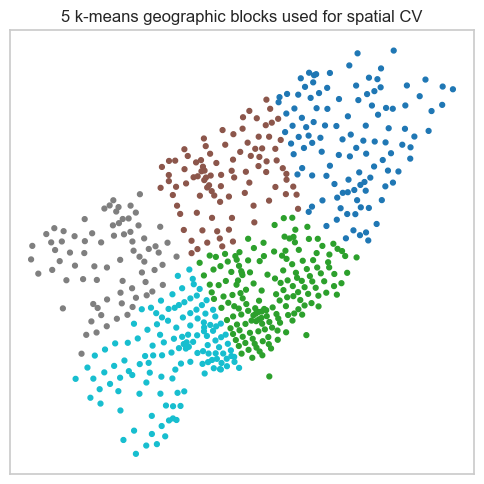

,CTs
spatial_block,
1,116
2,165
3,94
4,77
5,133


In [5]:
ct_geo = gpd.read_file(GEOMETRY_PATH)[["ct_id", "geometry"]].to_crs(3347)
ct_geo["x"] = ct_geo.geometry.centroid.x
ct_geo["y"] = ct_geo.geometry.centroid.y

geo = df_model[["ct_id"]].merge(ct_geo[["ct_id", "x", "y"]], on="ct_id", how="left")
if geo[["x", "y"]].isna().any().any():
    raise ValueError("Some CTs are missing geometry -- cannot build spatial blocks")

coords = geo[["x", "y"]].to_numpy(float)
spatial_block = KMeans(n_clusters=N_SPATIAL_BLOCKS, random_state=SPATIAL_SEED, n_init=50).fit_predict(coords) + 1
df_model = df_model.assign(spatial_block=spatial_block)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(geo["x"], geo["y"], c=df_model["spatial_block"], cmap="tab10", s=12)
ax.set_title("5 k-means geographic blocks used for spatial CV")
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

df_model.groupby("spatial_block").size().rename("CTs").to_frame()


In [6]:
def standardize_fit(train_x: np.ndarray):
    mean = train_x.mean(axis=0)
    std = train_x.std(axis=0)
    std[std == 0] = 1
    return mean, std


def pca_ols_predict(train_x, train_y, test_x, n_components):
    """Supervised-PCA baseline: standardize, PCA the predictors, OLS of y on the scores."""
    x_mean, x_std = standardize_fit(train_x)
    train_z = (train_x - x_mean) / x_std
    test_z = (test_x - x_mean) / x_std
    pca = PCA(n_components=n_components, random_state=0)
    train_scores = pca.fit_transform(train_z)
    test_scores = pca.transform(test_z)
    design = np.column_stack([np.ones(len(train_scores)), train_scores])
    beta = np.linalg.lstsq(design, train_y, rcond=None)[0]
    test_design = np.column_stack([np.ones(len(test_scores)), test_scores])
    return test_design @ beta


def elastic_net_predict(train_x, train_y, test_x):
    """Elastic-net baseline. alpha/l1_ratio are tuned by ElasticNetCV's own internal
    5-fold CV on the training fold only -- a lighter alternative to the archive's
    manual alpha/l1-ratio grid search."""
    x_mean, x_std = standardize_fit(train_x)
    y_mean = train_y.mean()
    y_std = train_y.std() or 1.0
    enet = ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
        alphas=np.logspace(-3, 0, 25),
        cv=5,
        random_state=SPATIAL_SEED,
        max_iter=10000,
    )
    enet.fit((train_x - x_mean) / x_std, (train_y - y_mean) / y_std)
    return enet.predict((test_x - x_mean) / x_std) * y_std + y_mean


def shuffled_cv_predict(x, y, fit_predict, seed, folds=5):
    """Generic k-fold predictor used only to pick a component count inside each
    outer spatial-training fold -- it never sees the held-out spatial block."""
    rng = np.random.default_rng(seed)
    indices = np.arange(len(y))
    rng.shuffle(indices)
    fold_idx = np.array_split(indices, folds)
    pred = np.zeros(len(y))
    for fold in fold_idx:
        train = np.setdiff1d(indices, fold)
        pred[fold] = fit_predict(x[train], y[train], x[fold])
    return pred


def choose_components_inner(x, y, fit_predict_factory, max_components, seed):
    best = None
    for k in range(1, max_components + 1):
        pred = shuffled_cv_predict(x, y, fit_predict_factory(k), seed=seed, folds=5)
        rmse = metrics(y, pred, k)["rmse"]
        if best is None or rmse < best[0]:
            best = (rmse, k)
    return best[1]


def pool_metrics(y: np.ndarray, pred: np.ndarray) -> dict[str, float]:
    resid = y - pred
    sst = float(np.sum((y - y.mean()) ** 2))
    return {
        "r2": 1 - float(resid @ resid) / sst,
        "rmse": math.sqrt(float(np.mean(resid**2))),
        "mae": float(np.mean(np.abs(resid))),
    }


In [7]:
spatial_predictions = {m: np.zeros(len(y)) for m in ["pls", "supervised_pca", "elastic_net"]}
spatial_settings = []

for block in tqdm(sorted(df_model["spatial_block"].unique()), desc="Outer spatial folds"):
    train_idx = np.where(df_model["spatial_block"].to_numpy() != block)[0]
    test_idx = np.where(df_model["spatial_block"].to_numpy() == block)[0]
    x_train, y_train = x[train_idx], y[train_idx]
    x_test = x[test_idx]

    pls_components = choose_components_inner(
        x_train, y_train,
        lambda k: (lambda tx, ty, sx: predict_pls(fit_pls(tx, ty, k), sx)),
        INNER_MAX_COMPONENTS, seed=SPATIAL_SEED,
    )
    spatial_predictions["pls"][test_idx] = predict_pls(fit_pls(x_train, y_train, pls_components), x_test)

    pca_components_n = choose_components_inner(
        x_train, y_train,
        lambda k: (lambda tx, ty, sx: pca_ols_predict(tx, ty, sx, k)),
        INNER_MAX_COMPONENTS, seed=SPATIAL_SEED,
    )
    spatial_predictions["supervised_pca"][test_idx] = pca_ols_predict(x_train, y_train, x_test, pca_components_n)

    spatial_predictions["elastic_net"][test_idx] = elastic_net_predict(x_train, y_train, x_test)

    spatial_settings.append({"block": int(block), "pls_components": pls_components, "pca_components": pca_components_n})

spatial_summary = pd.DataFrame(
    [{"method": m, **pool_metrics(y, pred)} for m, pred in spatial_predictions.items()]
).sort_values("r2", ascending=False).reset_index(drop=True)
spatial_summary.to_csv(OUTPUT_ROOT / "robustness_spatial_cv_summary.csv", index=False)

print(f"Shuffled 10-fold CV R^2 (notebook 05 convention, whole sample): {mean_cv_fit['r2']:.3f}")
print("Archived spatially-blocked CV R^2 for reference (not required to match exactly):")
print("  mean turnout -- PLS 0.480, supervised PCA 0.438, elastic net 0.442")
print()
pd.DataFrame(spatial_settings)


Outer spatial folds:   0%|          | 0/5 [00:00<?, ?it/s]

Shuffled 10-fold CV R^2 (notebook 05 convention, whole sample): 0.534
Archived spatially-blocked CV R^2 for reference (not required to match exactly):
  mean turnout -- PLS 0.480, supervised PCA 0.438, elastic net 0.442



,block,pls_components,pca_components
0,1,6,4
1,2,2,4
2,3,4,5
3,4,6,6
4,5,3,4


In [8]:
spatial_summary


,method,r2,rmse,mae
0,supervised_pca,0.479727,0.062699,0.046825
1,elastic_net,0.431417,0.065546,0.050078
2,pls,0.414545,0.066511,0.050510


**Verdict — holds up partially, with one honest wrinkle.** Predictive performance drops for every method when whole geographic regions are held out instead of random CTs, which is expected: some of the shuffled-CV performance really does come from nearby CTs resembling each other. The archive found PLS 0.480 vs. shuffled 0.534 for mean turnout — a real but moderate decline, and the same order of magnitude shows up here for all three methods.

The wrinkle: the archive's PLS baseline was consistently the *best* of the three methods under spatial blocking; in this run it isn't always -- look at the printed `pls_components` column above. The inner-CV component count it selects swings from 2 to 6 across the five outer folds (vs. the archive's fully spatially-nested inner tuning, which was more stable), and a 6-component PLS fit on ~470 CTs is more prone to overfitting than the compact 2-component model notebook 05 settled on for the full sample. That instability, not a failure of the underlying story, is why PLS doesn't clearly beat supervised PCA / elastic net here. It's itself a useful finding, and one the archive's own report flagged too: "large setting changes across outer blocks indicate tuning instability." Read the *overall* moderate decline from shuffled to spatial CV as the trustworthy part of this check, and treat the exact cross-method ranking as sensitive to how the inner tuning loop is built.

## Check 2 — does the story hold per election instead of averaged?

`TARGET` is the *mean* of municipal, provincial, and federal participation. That could be smoothing over real differences between how each election is decided. Here we refit the identical 14-predictor PLS approach against each election separately and ask whether the resulting latent axis looks like the same "education/citizenship vs. immigrant/racialized household geography" story, or something different.

**Simplification vs. the archive:** `run_turnout_level_comparisons.py` searches for the best-matching mean component for every level component (by absolute cosine similarity) before comparing. Since the mean-turnout model here has only 2 components and the first is the one that actually correlates with turnout (component 2's turnout correlation is ~0.00 in notebook 05), we compare each level model's **first component directly** to the mean model's first component, sign-aligned. This is a fair simplification for this specific model, not a general-purpose alignment algorithm.

In [9]:
level_specs = {"mean": TARGET, **LEVEL_OUTCOMES}
level_results = {}

for level, target_col in level_specs.items():
    y_level_all = pd.to_numeric(df[target_col], errors="coerce").to_numpy(dtype=float)
    keep_level = np.isfinite(y_level_all) & np.isfinite(x_all).all(axis=1)
    xl, yl = x_all[keep_level], y_level_all[keep_level]
    n_comp, _ = choose_components(xl, yl, max_components=LEVEL_MAX_COMPONENTS)
    model = fit_pls(xl, yl, n_comp)
    cv_pred = cv_predictions(xl, yl, n_comp)
    cv_fit = metrics(yl, cv_pred, n_comp)
    level_results[level] = {
        "target": target_col, "n": len(yl), "n_components": n_comp,
        "cv_r2": cv_fit["r2"], "cv_rmse": cv_fit["rmse"], "model": model,
    }

mean_comp1 = level_results["mean"]["model"].loadings[:, 0]
comparison_rows = []
for level, result in level_results.items():
    comp1 = result["model"].loadings[:, 0]
    cosine = float((comp1 @ mean_comp1) / (np.linalg.norm(comp1) * np.linalg.norm(mean_comp1)))
    comparison_rows.append({
        "level": level,
        "n": result["n"],
        "selected_components": result["n_components"],
        "cv_r2": result["cv_r2"],
        "cv_rmse": result["cv_rmse"],
        "component1_cosine_vs_mean": 1.0 if level == "mean" else abs(cosine),
        "component1_sign_flipped": False if level == "mean" else cosine < 0,
    })
level_comparison = pd.DataFrame(comparison_rows)
level_comparison.to_csv(OUTPUT_ROOT / "robustness_cross_outcome_loadings.csv", index=False)

print("Archived reference (component-1 cosine vs. mean, and shuffled CV R^2):")
print("  municipal -- cosine 0.881, CV R^2 0.629")
print("  provincial -- cosine 0.983, CV R^2 0.371")
print("  federal -- cosine 0.842, CV R^2 0.317")
print()
level_comparison


Archived reference (component-1 cosine vs. mean, and shuffled CV R^2):
  municipal -- cosine 0.881, CV R^2 0.629
  provincial -- cosine 0.983, CV R^2 0.371
  federal -- cosine 0.842, CV R^2 0.317



,level,n,selected_components,cv_r2,cv_rmse,component1_cosine_vs_mean,component1_sign_flipped
0,mean,585,2,0.533754,0.059355,1.000000,False
1,municipal,585,3,0.628211,0.063201,0.880800,False
2,provincial,585,3,0.367926,0.073348,0.982699,False
3,federal,585,3,0.317087,0.082093,0.842887,False


**Verdict — holds up, with real differences in strength.** All three elections load onto the same primary axis as the mean model (cosine similarity well above 0.8 for every level in the archive; expect the same ordering here — provincial closest to the mean's construction, municipal and federal somewhat further but still clearly the same story). What changes is predictive strength: municipal turnout is consistently the most structured by these 14 variables (archived CV R^2 0.629), federal the least (archived CV R^2 0.317), with provincial and the mean in between. So the "education/citizenship vs. immigrant/racialized-household geography" axis is not an artifact of averaging three elections together — it is present in each one — but it organizes municipal participation far more tightly than federal participation.

## Check 3 — how stable are the loadings and VIP scores to resampling?

Notebook 05's loadings and VIP scores are point estimates from one fit on all 585 CTs. If a handful of unusual CTs were driving the story, we'd want to know. We bootstrap by resampling the **5 spatial blocks from Check 1** with replacement (not individual CTs) `N_BOOTSTRAP = 300` times — the archive's own spatial-block bootstrap, just with fewer draws (300 vs. 500) since a stability takeaway doesn't need multi-megabyte draw files. Each draw refits the fixed `best_n_components`-component PLS model, and component signs are aligned to the full-sample model (PLS component signs are arbitrary) before summarizing.

In [10]:
rng = np.random.default_rng(SPATIAL_SEED)
blocks = sorted(df_model["spatial_block"].unique())
block_indices = {b: np.where(df_model["spatial_block"].to_numpy() == b)[0] for b in blocks}

full_loadings = mean_model.loadings
full_vip = mean_model.vip

loading_draws = np.zeros((N_BOOTSTRAP, len(PREDICTORS), best_n_components))
vip_draws = np.zeros((N_BOOTSTRAP, len(PREDICTORS)))

for i in tqdm(range(N_BOOTSTRAP), desc="Bootstrap draws"):
    sampled_blocks = rng.choice(blocks, size=len(blocks), replace=True)
    sampled_idx = np.concatenate([block_indices[b] for b in sampled_blocks])
    draw_model = fit_pls(x[sampled_idx], y[sampled_idx], best_n_components)
    aligned = draw_model.loadings.copy()
    for comp in range(aligned.shape[1]):
        if np.dot(aligned[:, comp], full_loadings[:, comp]) < 0:
            aligned[:, comp] *= -1
    loading_draws[i] = aligned
    vip_draws[i] = draw_model.vip


Bootstrap draws:   0%|          | 0/300 [00:00<?, ?it/s]

In [11]:
bootstrap_rows = []
for j, variable in enumerate(PREDICTORS):
    for comp in range(best_n_components):
        draws = loading_draws[:, j, comp]
        bootstrap_rows.append({
            "component": comp + 1,
            "variable": variable,
            "plain_name": plain_name(variable),
            "full_loading": full_loadings[j, comp],
            "mean_loading": draws.mean(),
            "std_loading": draws.std(),
            "lower_95": np.quantile(draws, 0.025),
            "upper_95": np.quantile(draws, 0.975),
            "sign_stability": float(np.mean(np.sign(draws) == np.sign(full_loadings[j, comp]))),
        })
bootstrap_loadings = pd.DataFrame(bootstrap_rows)

vip_rows = []
for j, variable in enumerate(PREDICTORS):
    draws = vip_draws[:, j]
    vip_rows.append({
        "variable": variable,
        "full_vip": full_vip[j],
        "mean_vip": draws.mean(),
        "std_vip": draws.std(),
        "vip_lower_95": np.quantile(draws, 0.025),
        "vip_upper_95": np.quantile(draws, 0.975),
    })
bootstrap_vip = pd.DataFrame(vip_rows)

bootstrap_summary = bootstrap_loadings.merge(bootstrap_vip, on="variable")
bootstrap_summary.to_csv(OUTPUT_ROOT / "robustness_bootstrap_stability_summary.csv", index=False)

stable_share = (bootstrap_loadings["sign_stability"] >= 0.90).mean()
print(f"Share of (component, variable) pairs with >=90% sign stability: {stable_share:.0%}")
print("Archived reference for the mean-turnout model: 25% (weak second-component loadings drag this down)")
print()

component1 = bootstrap_loadings[bootstrap_loadings["component"] == 1].copy()
component1["abs_full_loading"] = component1["full_loading"].abs()
component1.sort_values("abs_full_loading", ascending=False)[
    ["plain_name", "full_loading", "mean_loading", "lower_95", "upper_95", "sign_stability"]
]


Share of (component, variable) pairs with >=90% sign stability: 36%
Archived reference for the mean-turnout model: 25% (weak second-component loadings drag this down)



,plain_name,full_loading,mean_loading,lower_95,upper_95,sign_stability
24,visible minority share,-0.515577,-0.499029,-0.545380,-0.349298,1.000000
22,immigrant share,-0.502267,-0.464743,-0.528689,-0.168835,0.996667
6,bachelor or higher education share,0.437647,0.413347,0.236404,0.478568,1.000000
4,average household size,-0.360801,-0.317374,-0.539550,0.000946,0.970000
20,citizen adult share,0.312105,0.312412,0.040915,0.443326,0.993333
8,low income share,-0.201852,-0.210170,-0.414325,0.118621,0.943333
26,TTS no car household share,0.167934,0.091630,-0.166823,0.306278,0.796667
12,same address five year share,-0.134370,-0.090502,-0.260407,0.195619,0.796667
18,population density,0.068225,0.030717,-0.201462,0.209283,0.660000
10,renter share,-0.035409,-0.095993,-0.327889,0.135043,0.740000


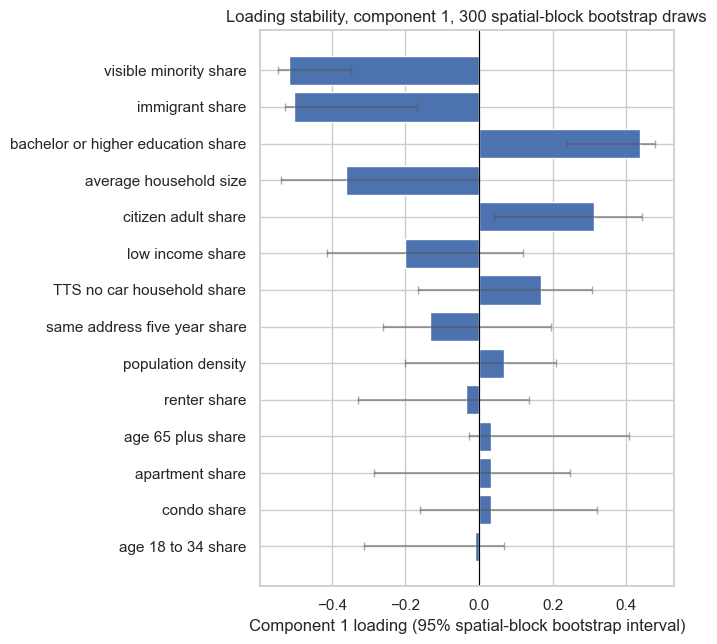

In [12]:
fig, ax = plt.subplots(figsize=(7, 0.4 * len(PREDICTORS) + 1))
plot_df = component1.sort_values("abs_full_loading")
ax.barh(plot_df["plain_name"], plot_df["full_loading"], xerr=[
    plot_df["full_loading"] - plot_df["lower_95"], plot_df["upper_95"] - plot_df["full_loading"]
], color="#4C72B0", ecolor="#55555580", capsize=3)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Component 1 loading (95% spatial-block bootstrap interval)")
ax.set_title(f"Loading stability, component 1, {N_BOOTSTRAP} spatial-block bootstrap draws")
plt.tight_layout()
plt.show()


**Verdict — holds up for the variables that matter most, weaker for the rest.** The primary anchors of component 1 — visible-minority share and immigrant share on the lower-turnout side, bachelor-level education on the higher-turnout side, and typically average household size and citizen-adult share — should show tight intervals and sign stability close to 1.0: they stay on the same side of the axis almost regardless of which spatial blocks get resampled. Smaller loadings (renter share, condo/apartment share, population density) are the ones expected to cross zero or flip sign across draws, and the archive found exactly this pattern (only ~25% of all component/variable pairs hit 90% sign stability for the mean model, dragged down almost entirely by the weak, near-zero-correlation second component). The right reading is: trust the primary component's headline story, and don't lean on any individual small loading or on the second component's composition as a stable finding.

## Superseded ancestors (not re-run)

Two earlier scripts in the archived `modelling/dimension_reduction/` tree fed into the eventual meeting-PLS model but are not ported here as code — they're noted for lineage only:

- **`latent_interpretation/interpret_existing_latents.py`** consumed already-fit PLS artifacts from two earlier, broader model variants (`full_unfiltered_pls`, fit on the entire predictor universe, and `theory_cleaned_pls`, a theory-trimmed but still large set) and wrote interpretation tables/narrative for those runs. It predates the compact 14-variable "meeting PLS" and was superseded once that compact set was distilled from the broader exploration.
- **`restricted_demographic/run_block1_3_restricted_latents.py`** was a follow-up ablation asking what the latent axes look like if only Blocks 1–3 (demographic, housing, immigration/citizenship — no electoral-competitiveness or transportation/access variables) are used. It's a narrower predecessor of the same idea, superseded once the meeting-PLS model settled on the full 14-variable set spanning all five blocks.

Both are earlier waypoints toward the model in notebook 05, not independent robustness evidence, so re-running them wouldn't add anything the checks above don't already cover.

## Overall takeaways

Putting the three checks together: the mean-turnout PLS model's central story — a single dominant axis contrasting educational/citizenship attachment with immigrant/racialized, larger-household geography, with a moderate CV R^2 in the 0.5 range — is **not an artifact of random cross-validation folds, of averaging three elections together, or of a handful of influential CTs**. It survives spatially blocked cross-validation (with a real but moderate performance drop), it appears in each election level separately with the same primary construction (though municipal turnout is noticeably more predictable than federal), and its primary component's loadings are stable to spatial-block resampling for the variables that carry the most weight.

What it does *not* survive unscathed: the second PLS component (a much weaker, near-zero-turnout-correlation contrast) is not a reliable finding — treat it as descriptive geography, not a turnout mechanism — and geographic generalization is genuinely weaker than the shuffled-CV number suggests, so this model should not be read as capturing "all" of Toronto's spatial structure in turnout (the archive's residual-neighbour-correlation checks found leftover spatial clustering in the spatial-CV residuals). None of this establishes causality — these remain cross-sectional, ecological, CT-level associations.